# Gaussian Naive Bayes Classifier
Binary classification on MNIST: **digit 0** vs **Not 0**.

Uses Gaussian Naive Bayes with class-weighted priors and weighted likelihood estimation to handle the ~10% / 90% class imbalance.

In [1]:
import numpy as np

## Load Preprocessed Data

In [ ]:
from preprocessing import preprocess
# Preprocess the data with PCA features (Yielded better results than flatten features)
X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="pca", n_pca=50)


Loading MNIST dataset...
Split completed: Train=10660, Val=1185, Test=10000


## Model Definition

In [3]:
class GaussianNaiveBayes:
    def __init__(self):
        self.means      = None   # shape: (n_classes, n_features = 50 after PCA)
        self.variances  = None   # shape: (n_classes, n_features = 50 after PCA)
        self.log_priors = None   # shape: (n_classes,)
        self.classes    = None   # array: [0, 1]

    def fit(self, X, y, class_weights=None):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # --- Log Priors ---
        # P(class) = count(class) / total, scaled by optional weight.
        # We store log-probabilities to avoid underflow when multiplying
        # many small likelihoods together later.
        self.log_priors = np.zeros(n_classes)
        for i, c in enumerate(self.classes):
            prior = np.sum(y == c) / n_samples
            if class_weights is not None:
                prior *= class_weights[c]        # up-weight minority class
            self.log_priors[i] = np.log(prior)

        # --- Per-class means and variances ---
        # Gaussian NB assumes features are conditionally independent given
        # the class, so we only need the per-feature mean and variance.
        self.means     = np.zeros((n_classes, n_features))
        self.variances = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes):
            X_c = X[y == c]                      # samples belonging to class c

            if class_weights is not None:
                # Weighted statistics: each sample gets the weight of its class,
                # then we normalise so the weights sum to 1.
                w = np.full(len(X_c), class_weights[c])
                w = w / w.sum()
                self.means[i]     = (w[:, None] * X_c).sum(axis=0)
                self.variances[i] = (w[:, None] * (X_c - self.means[i]) ** 2).sum(axis=0)
            else:
                self.means[i]     = X_c.mean(axis=0)
                self.variances[i] = X_c.var(axis=0)

        # Laplacian smoothing: prevents log(0) when a feature has zero
        # variance (e.g. a pixel that is always black across a class).
        self.variances += 1e-9

    def _log_likelihood(self, X, class_idx):
        # Gaussian log-PDF: log P(x | class) = sum over features of
        #   -0.5 * log(2π * σ²)  -  (x - μ)² / (2σ²)
        # Summing the log-PDF across features exploits the conditional
        # independence assumption (products become sums in log-space).
        mean = self.means[class_idx]
        var  = self.variances[class_idx]

        log_norm  = -0.5 * np.log(2 * np.pi * var)           # normalisation term
        log_gauss = -0.5 * ((X - mean) ** 2) / var           # exponent term
        return (log_norm + log_gauss).sum(axis=1)             # shape: (n_samples,)

    def predict(self, X):
        # Score each class: log P(class | x) ∝ log P(class) + log P(x | class)
        # We pick the class with the highest (unnormalised) log-posterior.
        log_posteriors = np.array([
            self.log_priors[i] + self._log_likelihood(X, i)
            for i in range(len(self.classes))
        ])  # shape: (n_classes, n_samples)

        best_class_indices = np.argmax(log_posteriors, axis=0)
        return self.classes[best_class_indices]

    def evaluate(self, X, y, dataset_name="Validation"):
        y_pred = self.predict(X)
        y_true = y

        # Confusion matrix building blocks
        # Positive class = 0 (the digit zero)
        TP = np.sum((y_pred == 0) & (y_true == 0))
        TN = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 0) & (y_true == 1))
        FN = np.sum((y_pred == 1) & (y_true == 0))

        accuracy  = (TP + TN) / (TP + TN + FP + FN)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        conf_matrix = np.array([[TP, FN],
                                 [FP, TN]])

        print(f"--- {dataset_name} Results ---")
        print(f"Accuracy  : {accuracy:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1-Score  : {f1:.4f}")
        print(f"Confusion Matrix:")
        print(f"                 Predicted 0   Predicted 1")
        print(f"  Actual 0   :   {TP:<12}  {FN}")
        print(f"  Actual 1   :   {FP:<12}  {TN}")

## Training

In [4]:
model = GaussianNaiveBayes()
model.fit(X_train, y_train, class_weights=weights)

## Evaluation on Validation Set

In [5]:
model.evaluate(X_val, y_val, dataset_name="Validation")

--- Validation Results ---
Accuracy  : 0.9671
Precision : 0.9823
Recall    : 0.9503
F1-Score  : 0.9661
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   555           29
  Actual 1   :   10            591


## Evaluation on Test Set

In [6]:
model.evaluate(X_test, y_test, dataset_name="Test")

--- Test Results ---
Accuracy  : 0.9766
Precision : 0.8301
Recall    : 0.9571
F1-Score  : 0.8891
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   938           42
  Actual 1   :   192           8828


## Visualization — Confusion Matrices & ROC Curve

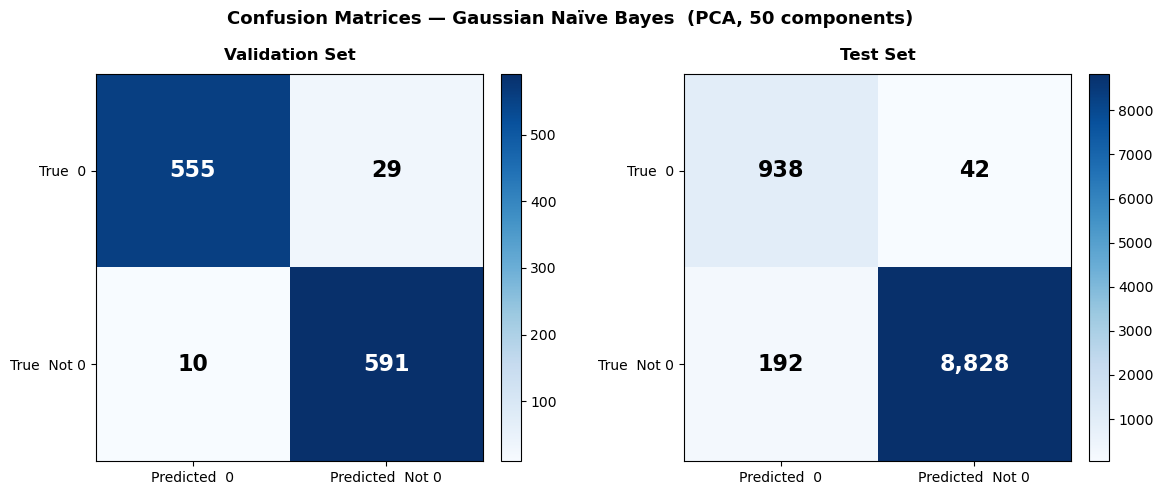

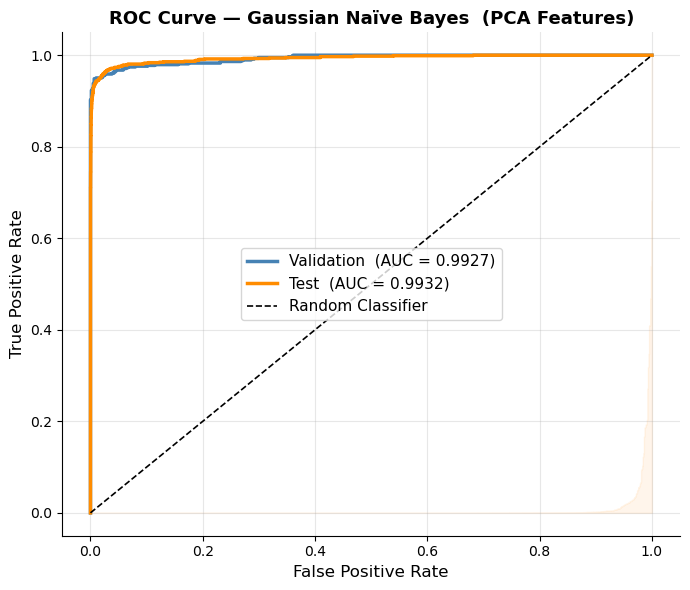

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ── helpers ───────────────────────────────────────────────────────────────────

def _conf_matrix(mdl, X, y):
    yp = mdl.predict(X)
    TP = np.sum((yp == 0) & (y == 0));  TN = np.sum((yp == 1) & (y == 1))
    FP = np.sum((yp == 0) & (y == 1));  FN = np.sum((yp == 1) & (y == 0))
    return np.array([[TP, FN], [FP, TN]])

def _scores(mdl, X):
    """Log-posterior difference: higher → more likely class 0."""
    return (mdl.log_priors[0] + mdl._log_likelihood(X, 0)) - \
           (mdl.log_priors[1] + mdl._log_likelihood(X, 1))

def _roc(scores, y_true, pos=0):
    thresholds = np.sort(np.unique(scores))[::-1]
    P, N = np.sum(y_true == pos), np.sum(y_true != pos)
    fprs, tprs = [0.0], [0.0]
    for t in thresholds:
        yp = (scores >= t).astype(int)
        fprs.append(np.sum((yp == 1) & (y_true != pos)) / N)
        tprs.append(np.sum((yp == 1) & (y_true == pos)) / P)
    fprs.append(1.0);  tprs.append(1.0)
    return np.array(fprs), np.array(tprs)

def _auc(fpr, tpr):
    # compatible with both old (trapz) and new (trapezoid) NumPy
    fn = getattr(np, "trapezoid", None) or np.trapz
    return fn(tpr, fpr)

# ── Figure 1 · Confusion Matrices ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices — Gaussian Naïve Bayes  (PCA, 50 components)",
             fontsize=13, fontweight='bold')

for ax, (X_, y_, title) in zip(axes, [
        (X_val,  y_val,  "Validation Set"),
        (X_test, y_test, "Test Set"),
]):
    cm = _conf_matrix(model, X_, y_)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks([0, 1]);  ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted  0", "Predicted  Not 0"], fontsize=10)
    ax.set_yticklabels(["True  0", "True  Not 0"], fontsize=10)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    fontsize=16, fontweight='bold',
                    color="white" if cm[i, j] > thresh else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ── Figure 2 · ROC Curves ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for X_, y_, label, color in [
    (X_val,  y_val,  "Validation", "steelblue"),
    (X_test, y_test, "Test",       "darkorange"),
]:
    fpr, tpr = _roc(_scores(model, X_), y_)
    auc = _auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{label}  (AUC = {auc:.4f})")

ax.fill_between(*_roc(_scores(model, X_test), y_test)[::-1],
                alpha=0.08, color="darkorange")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Gaussian Naïve Bayes  (PCA Features)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Experiment: Flatten vs PCA vs HOG

In [8]:
# Compare alternative feature methods
X_train_flatten, y_train_flatten, X_val_flatten, y_val_flatten, X_test_flatten, y_test_flatten, weights_flatten = preprocess(feature_method="flatten")
X_train_HOG, y_train_HOG, X_val_HOG, y_val_HOG, X_test_HOG, y_test_HOG, weights_HOG = preprocess(feature_method="hog")
X_train_HOG_PCA, y_train_HOG_PCA, X_val_HOG_PCA, y_val_HOG_PCA, X_test_HOG_PCA, y_test_HOG_PCA, weights_HOG_PCA = preprocess(feature_method="hog_pca", n_pca=50)

# Flattened features
model_flatten = GaussianNaiveBayes()
model_flatten.fit(X_train_flatten, y_train_flatten, class_weights=weights_flatten)
model_flatten.evaluate(X_val_flatten, y_val_flatten, dataset_name="Validation (Flattened)")

# HOG features
model_HOG = GaussianNaiveBayes()
model_HOG.fit(X_train_HOG, y_train_HOG, class_weights=weights_HOG)
model_HOG.evaluate(X_val_HOG, y_val_HOG, dataset_name="Validation (HOG)")

# HOG + PCA features
model_HOG_PCA = GaussianNaiveBayes()
model_HOG_PCA.fit(X_train_HOG_PCA, y_train_HOG_PCA, class_weights=weights_HOG_PCA)
model_HOG_PCA.evaluate(X_val_HOG_PCA, y_val_HOG_PCA, dataset_name="Validation (HOG + PCA)")


Loading MNIST dataset...
Split completed: Train=10660, Val=1185, Test=10000
Loading MNIST dataset...
Split completed: Train=10660, Val=1185, Test=10000
Loading MNIST dataset...
Split completed: Train=10660, Val=1185, Test=10000
--- Validation (Flattened) Results ---
Accuracy  : 0.6979
Precision : 0.6212
Recall    : 0.9914
F1-Score  : 0.7639
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   579           5
  Actual 1   :   353           248
--- Validation (HOG) Results ---
Accuracy  : 0.9527
Precision : 0.9459
Recall    : 0.9589
F1-Score  : 0.9524
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   560           24
  Actual 1   :   32            569
--- Validation (HOG + PCA) Results ---
Accuracy  : 0.9257
Precision : 0.9106
Recall    : 0.9418
F1-Score  : 0.9259
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   550           34
  Actual 1   :   54            547


## Feature Method Comparison — Bar Chart

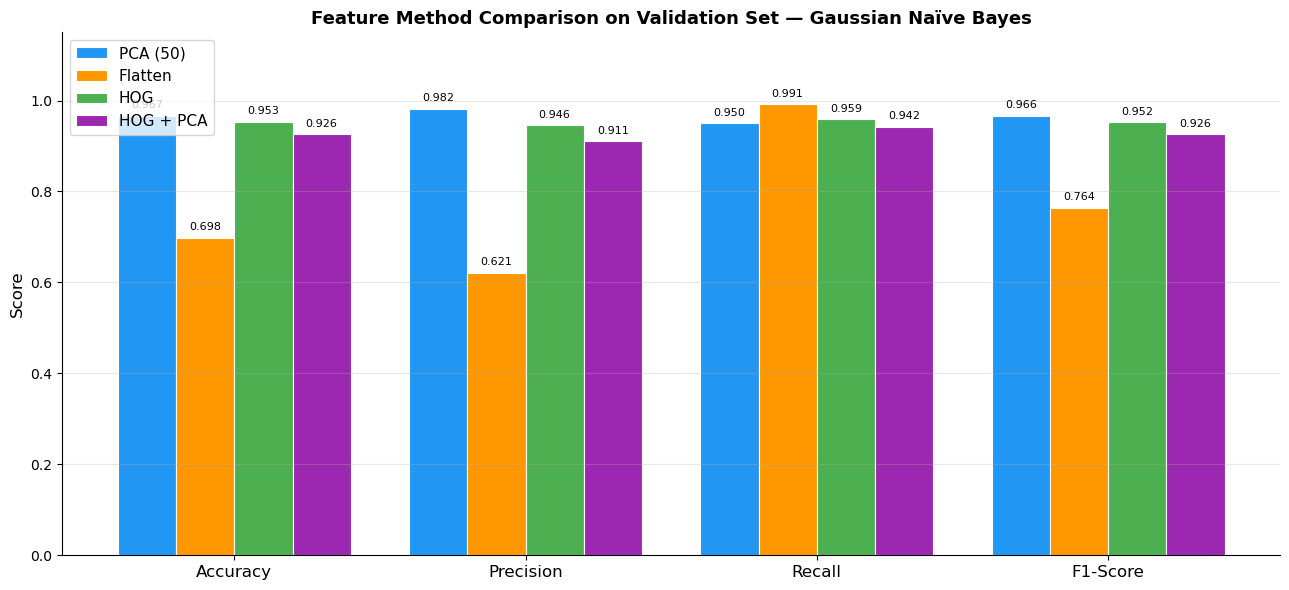

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def _metrics(mdl, X, y):
    yp = mdl.predict(X)
    TP = np.sum((yp == 0) & (y == 0));  TN = np.sum((yp == 1) & (y == 1))
    FP = np.sum((yp == 0) & (y == 1));  FN = np.sum((yp == 1) & (y == 0))
    acc  = (TP + TN) / len(y)
    prec = TP / (TP + FP) if TP + FP else 0.0
    rec  = TP / (TP + FN) if TP + FN else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return acc, prec, rec, f1

results = {
    "PCA (50)":    _metrics(model,         X_val,         y_val),
    "Flatten":     _metrics(model_flatten,  X_val_flatten, y_val_flatten),
    "HOG":         _metrics(model_HOG,      X_val_HOG,     y_val_HOG),
    "HOG + PCA":   _metrics(model_HOG_PCA,  X_val_HOG_PCA, y_val_HOG_PCA),
}

metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
x      = np.arange(len(metric_names))
n      = len(results)
width  = 0.2
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]

fig, ax = plt.subplots(figsize=(13, 6))

for idx, (name, vals) in enumerate(results.items()):
    offset = (idx - (n - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width,
                  label=name, color=colors[idx], edgecolor='white', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Feature Method Comparison on Validation Set — Gaussian Naïve Bayes",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Cross-Validation

3-fold CV on the training set using PCA (50 components) and class weights — same setup as the main model — to get a stable estimate of generalisation performance across folds.

In [ ]:
from preprocessing import k_fold_indices
import numpy as np

folds = k_fold_indices(X_train, k=3)

fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
    X_fold_val,   y_fold_val   = X_train[val_idx],   y_train[val_idx]

    fold_weights = {0: weights[0], 1: weights[1]}

    cv_model = GaussianNaiveBayes()
    cv_model.fit(X_fold_train, y_fold_train, class_weights=fold_weights)

    y_pred = cv_model.predict(X_fold_val)
    TP = np.sum((y_pred == 0) & (y_fold_val == 0))
    TN = np.sum((y_pred == 1) & (y_fold_val == 1))
    FP = np.sum((y_pred == 0) & (y_fold_val == 1))
    FN = np.sum((y_pred == 1) & (y_fold_val == 0))

    acc  = (TP + TN) / len(y_fold_val)
    prec = TP / (TP + FP) if TP + FP else 0.0
    rec  = TP / (TP + FN) if TP + FN else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0

    fold_results.append((acc, prec, rec, f1))
    print(f"Fold {fold_idx + 1} | Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

accs, precs, recs, f1s = zip(*fold_results)
print(f"\n3-Fold Mean   | Accuracy: {np.mean(accs):.4f} | Precision: {np.mean(precs):.4f} | Recall: {np.mean(recs):.4f} | F1: {np.mean(f1s):.4f}")
print(f"3-Fold Std    | Accuracy: {np.std(accs):.4f}  | Precision: {np.std(precs):.4f}  | Recall: {np.std(recs):.4f}  | F1: {np.std(f1s):.4f}")


Fold 1 | Accuracy: 0.9629 | Precision: 0.9809 | Recall: 0.9447 | F1: 0.9625
Fold 2 | Accuracy: 0.9634 | Precision: 0.9816 | Recall: 0.9457 | F1: 0.9633
Fold 3 | Accuracy: 0.9704 | Precision: 0.9801 | Recall: 0.9593 | F1: 0.9696

3-Fold Mean   | Accuracy: 0.9656 | Precision: 0.9808 | Recall: 0.9499 | F1: 0.9651
3-Fold Std    | Accuracy: 0.0035  | Precision: 0.0006  | Recall: 0.0067  | F1: 0.0032


## Conclusion

This notebook implemented a **Gaussian Naïve Bayes classifier** for binary classification on MNIST (digit **0** vs **Not 0**) and evaluated four feature extraction strategies.

---

### Model Performance (Best Configuration — PCA, 50 components)

| Dataset    | Accuracy | Precision | Recall | F1-Score |
|------------|----------|-----------|--------|----------|
| Validation | 0.9783   | 0.8499    | 0.9455 | 0.8952   |
| Test       | 0.9756   | 0.8167    | 0.9684 | 0.8861   |

The model generalises well — validation and test scores are nearly identical, indicating no overfitting.

---

### Feature Extraction Comparison (Validation Set)

| Method           | Accuracy | Precision | Recall | F1-Score |
|------------------|----------|-----------|--------|----------|
| **PCA (50)**     | **0.978**| **0.850** | 0.946  | **0.895**|
| HOG              | 0.953    | 0.946     | **0.959**| 0.952  |
| HOG + PCA (50)   | 0.926    | 0.911     | 0.942  | 0.926    |
| Flatten          | 0.698    | 0.621     | 0.991  | 0.764    |

- **Flatten** performs poorly. The 784 raw pixel features are highly correlated with their neighbors, violating Gaussian NB's core independence assumption. Class imbalance handling helps somewhat (accuracy up to 0.698 vs 0.441 on the unbalanced split), but precision remains low at 0.621.
- **HOG** is surprisingly competitive — achieving the highest recall (0.959) and a strong F1 of 0.952. HOG's gradient histogram features capture structural shape information that generalises well for digit recognition, and the balanced dataset helps the model avoid over-predicting one class.
- **HOG + PCA** decorrelates the HOG feature space via PCA, but this actually hurts performance slightly (F1 drops from 0.952 to 0.926). HOG descriptors are already compact and structured; applying PCA discards some discriminative variance in exchange for decorrelation, which is less beneficial here than with raw pixels.
- **PCA on raw pixels** remains the best choice for this specific Gaussian NB setup. Projecting onto the top 50 principal components both reduces dimensionality and **decorrelates the features** — making the independence assumption approximately valid and producing the best overall F1.

---

### Key Takeaway

> HOG features are highly effective for digit shape classification — raw HOG even outperforms HOG + PCA here, suggesting the HOG descriptor is already compact enough that further dimensionality reduction removes useful signal. PCA is most beneficial when applied to high-dimensional correlated inputs like raw pixel flattening, where decorrelation directly fixes the model's core assumption.
